# **LỰA CHỌN A - ẢNH**

## **Bài 1 - Biểu diễn dữ liệu thành ma trận & độ tương đồng**

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import os

### **1.1. Biến dữ liệu thành ma trận**

In [153]:
folder_path = "pokemons/"
img_array = []
uniform_size = (128, 128)


for file in os.listdir(folder_path):
    if file.endswith('.jpg'):
        img_path = os.path.join(folder_path, file)
        img = Image.open(img_path).convert('L')
        img = img.resize(uniform_size)

        img = np.array(img, dtype=float)
        img = img.flatten()
        img_array.append(img)


X = np.array(img_array)
print(f"Kích thước của X: {X.shape}")

Kích thước của X: (9, 16384)


* Mỗi hàng đại diện cho một bức ảnh với độ dài bằng tổng số pixel có trong bức ảnh đó.
* Mỗi cột đại diện cho vị trí của từng pixel trên mỗi bức ảnh.
* Giá trị của mỗi phần tử là độ sáng từ 0 đến 255 của từng pixel trên bức ảnh.

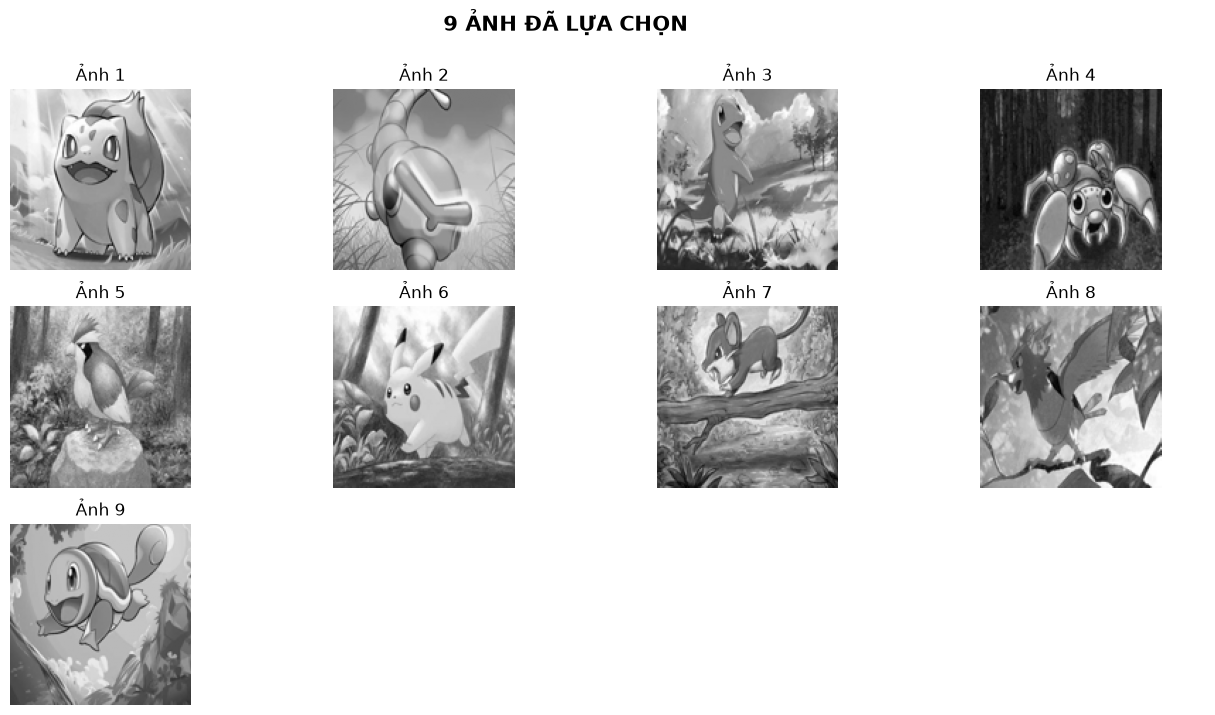

In [154]:
count = 0
cols = 4
rows = len(img_array)//4 + (1 if len(img_array) % 4 != 0 else 0)
fig, axs = plt.subplots(rows, cols, figsize=(16, 8))
fig.suptitle(f"{len(img_array)} ẢNH ĐÃ LỰA CHỌN", fontsize=15, fontweight='bold')
for i in range(0, rows):
    for j in range(0, cols):
        if count < len(img_array):
            current_img = X[count].reshape(uniform_size)
            axs[i][j].set_title(f"Ảnh {count + 1}")
            axs[i][j].imshow(current_img, cmap='gray')
            axs[i][j].axis('off')
        else:
            axs[i][j].axis('off')
        count += 1

plt.show()

### **1.2. Phép toán cơ bản**

In [155]:
X_mean = np.mean(X, axis=0)
print(f"Kích thước của X: {X.shape}")
print(f"Kích thước của X_mean: {X_mean.shape}")

X_centered = X - X_mean
print(f"Kích thước của X_centered: {X_centered.shape}")

Kích thước của X: (9, 16384)
Kích thước của X_mean: (16384,)
Kích thước của X_centered: (9, 16384)


#### **Minh họa quy tắc broadcasting:**
`X_mean` là một mảng 1D có chiều dài $16384$, khi lấy `X` là một ma trận $9 \times 16384$ trừ cho `X_mean`, quy tắc _broadcasting_ được áp dụng bằng cách lấy từng vector hàng trên `X` trừ cho `X_mean`.
Kết quả thu được là một ma trận `X_centered` có cùng kích cỡ với `X`

### **1.3. Cosine similarity**

In [156]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

test = cosine_similarity(X)
np.set_printoptions(precision=4)
print("Ma trận tương đồng:")
print(test)
print(f"Kích thước của ma trận tương đồng: {test.shape}")


Ma trận tương đồng:
[[1.     0.929  0.9233 0.8198 0.9431 0.9383 0.9368 0.9138 0.9349]
 [0.929  1.     0.93   0.8854 0.952  0.9363 0.9432 0.9441 0.9266]
 [0.9233 0.93   1.     0.8499 0.9348 0.934  0.9325 0.9161 0.9124]
 [0.8198 0.8854 0.8499 1.     0.8904 0.8592 0.8589 0.8872 0.8701]
 [0.9431 0.952  0.9348 0.8904 1.     0.953  0.9551 0.9393 0.9529]
 [0.9383 0.9363 0.934  0.8592 0.953  1.     0.9538 0.911  0.9391]
 [0.9368 0.9432 0.9325 0.8589 0.9551 0.9538 1.     0.9253 0.9423]
 [0.9138 0.9441 0.9161 0.8872 0.9393 0.911  0.9253 1.     0.9167]
 [0.9349 0.9266 0.9124 0.8701 0.9529 0.9391 0.9423 0.9167 1.    ]]
Kích thước của ma trận tương đồng: (9, 9)


### **1.4. Truy vấn**

In [157]:
def search(query, top_k = 3):
    if query.ndim == 1:
        query = query.reshape(1, -1)

    similarities = cosine_similarity(X, query).flatten()

    greatest_to_least_similarities = np.argsort(similarities)[::-1]
    top_k_greatest_similarities = greatest_to_least_similarities[:top_k]

    top_k_cosine = similarities[top_k_greatest_similarities]

    return top_k_greatest_similarities, top_k_cosine

top_k = 8
indices, cosines = search(X[0], top_k)

print(f"Các ảnh giống với ảnh 1 nhất kèm điểm cosine:")
for i in range(0, top_k):
    print(f"Ảnh {indices[i]}: {cosines[i]:.4f}")

Các ảnh giống với ảnh 1 nhất kèm điểm cosine:
Ảnh 0: 1.0000
Ảnh 4: 0.9431
Ảnh 5: 0.9383
Ảnh 6: 0.9368
Ảnh 8: 0.9349
Ảnh 1: 0.9290
Ảnh 2: 0.9233
Ảnh 7: 0.9138


### **1.5. Nhận xét**

Ảnh 5 giống ảnh 7 nhất với tỷ lệ: 0.9551
Ảnh 1 ít giống ảnh 4 nhất với tỷ lệ: 0.8198


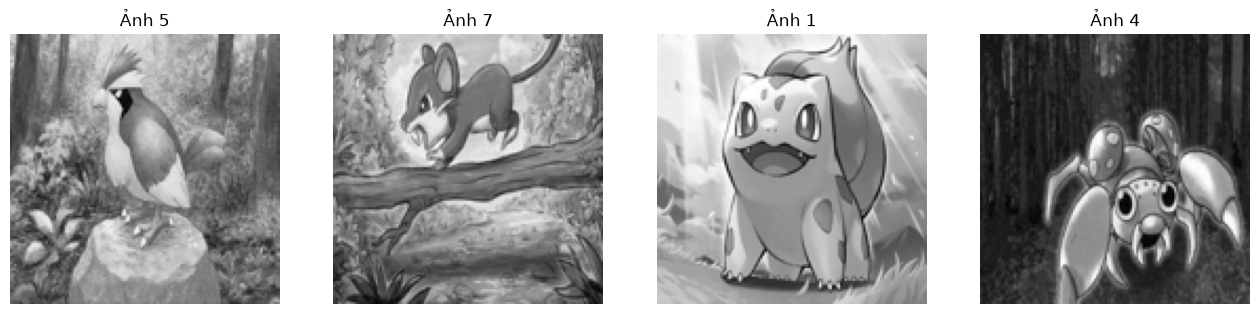

In [158]:
evaluate_matrix = cosine_similarity(X)

def find_max_similar(evaluate_matrix):
    r, c = evaluate_matrix.shape
    idx1 = 0
    idx2 = 0
    max_similar = 0
    for i in range(0, r):
        for j in range(0, c):
            if i == j:
                continue
            if evaluate_matrix[i][j] > max_similar:
                max_similar = evaluate_matrix[i][j]
                idx1 = i
                idx2 = j
    return (idx1, idx2, max_similar)

def find_min_similar(evaluate_matrix):
    r, c = evaluate_matrix.shape
    idx1 = 0
    idx2 = 0
    min_similar = 1
    for i in range(0, r):
        for j in range(0, c):
            if i == j:
                continue
            if evaluate_matrix[i][j] < min_similar:
                min_similar = evaluate_matrix[i][j]
                idx1 = i
                idx2 = j
    return (idx1, idx2, min_similar)

indices_max_min = [0]*4

indices_max_min[0], indices_max_min[1], max_similar = find_max_similar(evaluate_matrix)
print(f"Ảnh {indices_max_min[0]+1} giống ảnh {indices_max_min[1]+1} nhất với tỷ lệ: {max_similar:.4f}")

indices_max_min[2], indices_max_min[3], min_similar = find_min_similar(evaluate_matrix)
print(f"Ảnh {indices_max_min[2]+1} ít giống ảnh {indices_max_min[3]+1} nhất với tỷ lệ: {min_similar:.4f}")

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i in range(0, 4):
    axs[i].set_title(f"Ảnh {indices_max_min[i] + 1}")
    axs[i].imshow(X[indices_max_min[i]].reshape(uniform_size), cmap='gray')
    axs[i].axis('off')


#### **Nhận xét**:
* Kết quả trả về _Ảnh 5_ giống _Ảnh 7_ nhất và _Ảnh 1_ khác _Ảnh 4_ nhất.
* Sự giống nhau được xét trên sự tương đồng giữa các pixel ảnh tương ứng trên mỗi cặp ảnh. Do đó các bức ảnh có càng nhiều pixel tương ứng có độ sáng giống nhau được cho là càng giống nhau và ngược lại bất kể nội dung bức ảnh. Trong ví dụ về ảnh các pokemon, _Ảnh 5_ giống _Ảnh 7_ nhiều nhất về cường độ sáng dù 2 loài pokemon là khác nhau. Ngược lại, _Ảnh 1_ và _Ảnh 4_ là hai tấm ảnh có độ sáng chênh lệch nhiều nhất nên được cho là hai bức ảnh khác nhau nhất.

## **Bài 2 - Biến đổi tuyến tính & SVD**

### **2.1. Biến đổi tuyến tính**

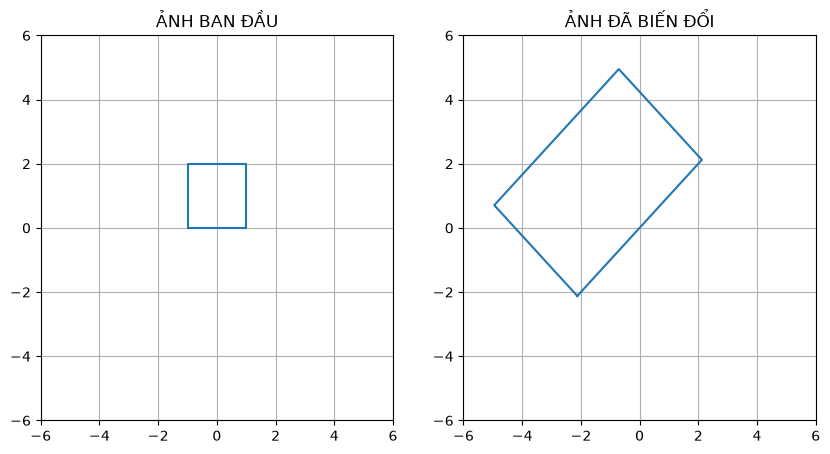

In [159]:
x_before = np.array([-1, 1, 1, -1, -1])
y_before = np.array([0, 0, 2, 2, 0])

points_before = np.array([x_before, y_before])

theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta),  np.cos(theta)]])

S = np.array([[3, 0],
              [0, 2]])

points_after = R @ S @ points_before

x_after = points_after[0, :]
y_after = points_after[1, :]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].set_title("ẢNH BAN ĐẦU")
axs[0].plot(x_before, y_before)
axs[0].set_xlim(-6, 6)
axs[0].set_ylim(-6, 6)
axs[0].grid(True)

axs[1].set_title("ẢNH ĐÃ BIẾN ĐỔI")
axs[1].plot(x_after, y_after)
axs[1].set_xlim(-6, 6)
axs[1].set_ylim(-6, 6)
axs[1].grid(True)
plt.show()

### **2.2. Nén ảnh bằng SVD**

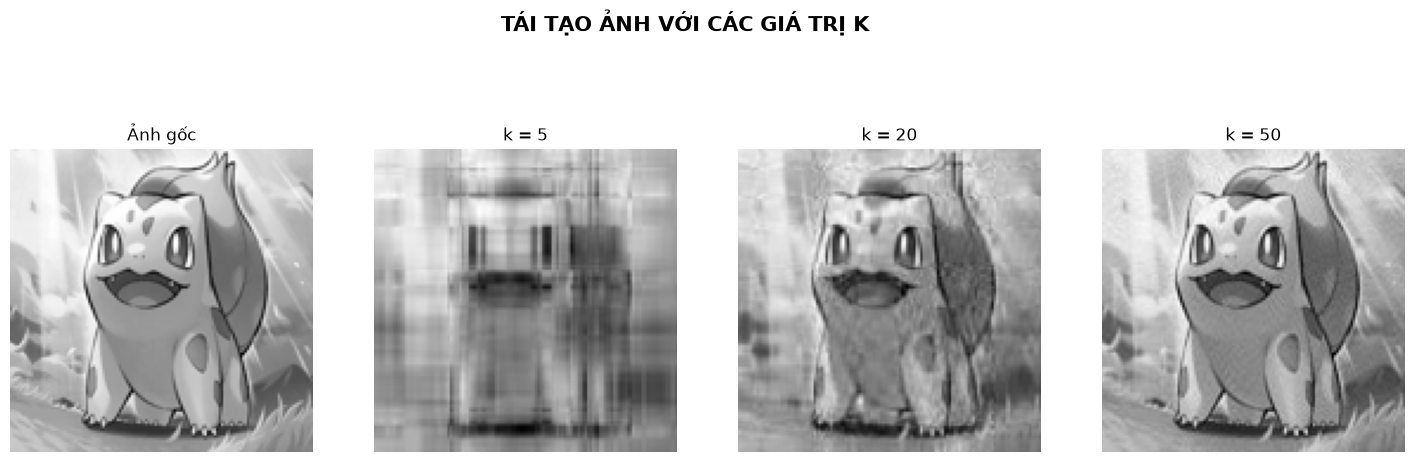

In [160]:
M = X[0].reshape(uniform_size)

U, S, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k_values = [5, 20, 50]

fig, axs = plt.subplots(1, len(k_values) + 1, figsize=(18, 6))
fig.suptitle("TÁI TẠO ẢNH VỚI CÁC GIÁ TRỊ K", fontsize=15, fontweight='bold')

axs[0].set_title("Ảnh gốc")
axs[0].imshow(M, cmap='gray')
axs[0].axis('off')

for i in range(0, len(k_values)):
    axs[i + 1].set_title(f"k = {k_values[i]}")
    axs[i + 1].imshow(reconstruct(k_values[i]), cmap='gray')
    axs[i + 1].axis('off')

plt.show()

### **2.3. Đánh giá**

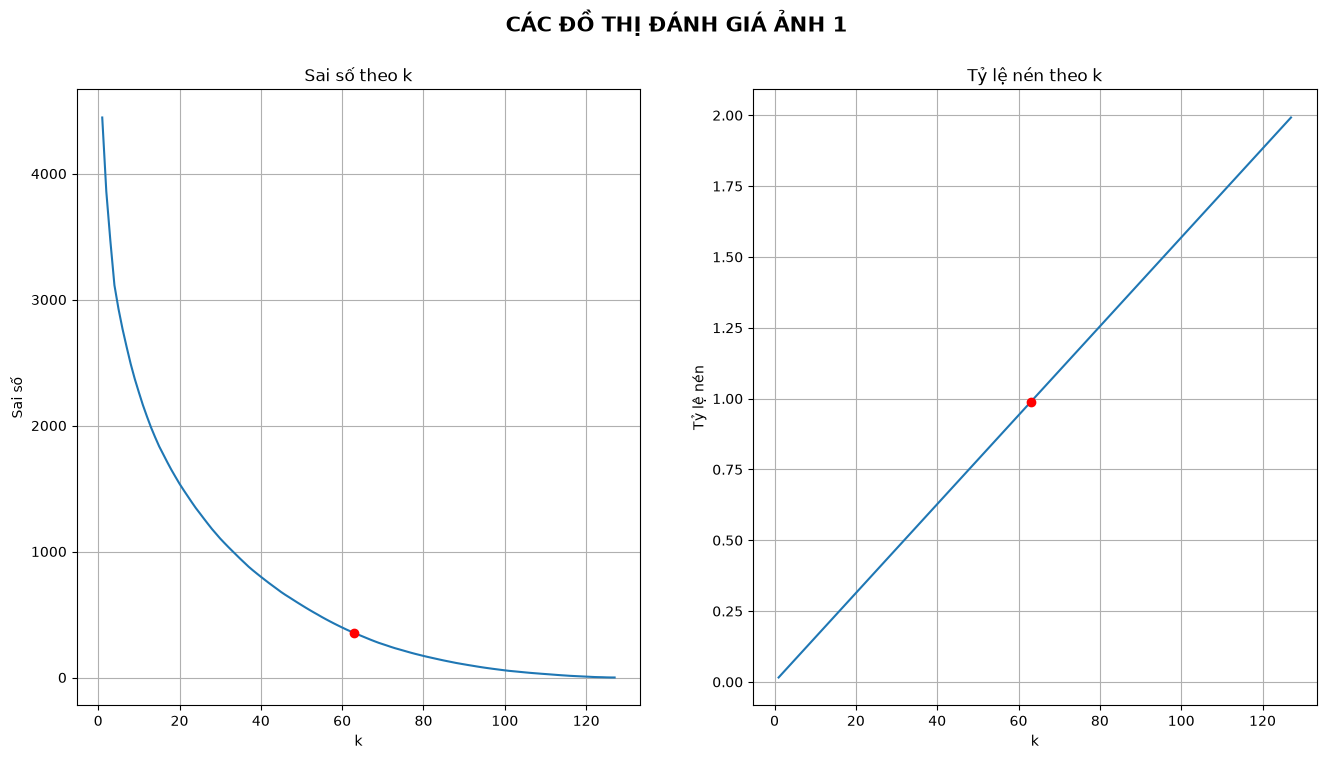

In [161]:
m, n = M.shape
k_max = min(m ,n)
k_range = range(1, k_max, 1)

errors = []
compression_ratios = []

for k in k_range:
    M_reconstructed = reconstruct(k)

    error = np.linalg.norm(M - M_reconstructed, ord='fro')
    errors.append(error)

    compression_ratio = (k*(m + n + 1)) / (m * n)
    compression_ratios.append(compression_ratio)

k_ratio_1 = int((m * n) / (m + n + 1))

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("CÁC ĐỒ THỊ ĐÁNH GIÁ ẢNH 1", fontsize=15, fontweight='bold')

axs[0].set_title("Sai số theo k")
axs[0].plot(k_range, errors)
axs[0].plot(k_range[k_ratio_1 - 1], errors[k_ratio_1 - 1], 'ro')
axs[0].set_xlabel("k")
axs[0].set_ylabel("Sai số")
axs[0].grid(True)

axs[1].set_title("Tỷ lệ nén theo k")
axs[1].plot(k_range, compression_ratios)
axs[1].plot(k_range[k_ratio_1 - 1], compression_ratios[k_ratio_1 - 1], 'ro')
axs[1].set_xlabel("k")
axs[1].set_ylabel("Tỷ lệ nén")
axs[1].grid(True)

plt.show()

### **2.4. Nhận xét:**
* Chấm đỏ trên hai đồ thị là mức `k` tương ứng tại đó _Tỷ lệ nén_ bằng $1$.
* Đồ thị bên phải cho biết quan hệ tuyến tính giữa `k` và _Tỷ lệ nén_, `k` càng tăng thì _Tỷ lệ nén_ càng tăng và có thể vượt dung lượng ban đầu của bức ảnh. Do đó ta ưu tiên chọn các giá trị `k` nhỏ hơn giá trị `k` ở chấm đỏ để dữ liệu được nén giúp giảm dung lượng lưu trữ.
* Đồ thị bên trái cho biết mối quan hệ giữ `k` và _Sai số_ của bức ảnh sau khi khôi phục. `k` càng nhỏ _Sai số_ càng tăng mạnh do đó ta cần lưu ý chọn giá trị `k` tại điểm đồ thị có độ cong càng thoải để đảm bảo sai số và tỷ lệ nén.
* Trong phân tích SVD, việc giữ lại `k` trục lớn nhất tương ứng với với giữ lại `k` thông tin chính của một dữ liệu, từ đó ta có thể triệt tiêu một số thông tin nhiễu và giữ lại các đặc trưng nhất của dữ liệu.

## **BONUS**

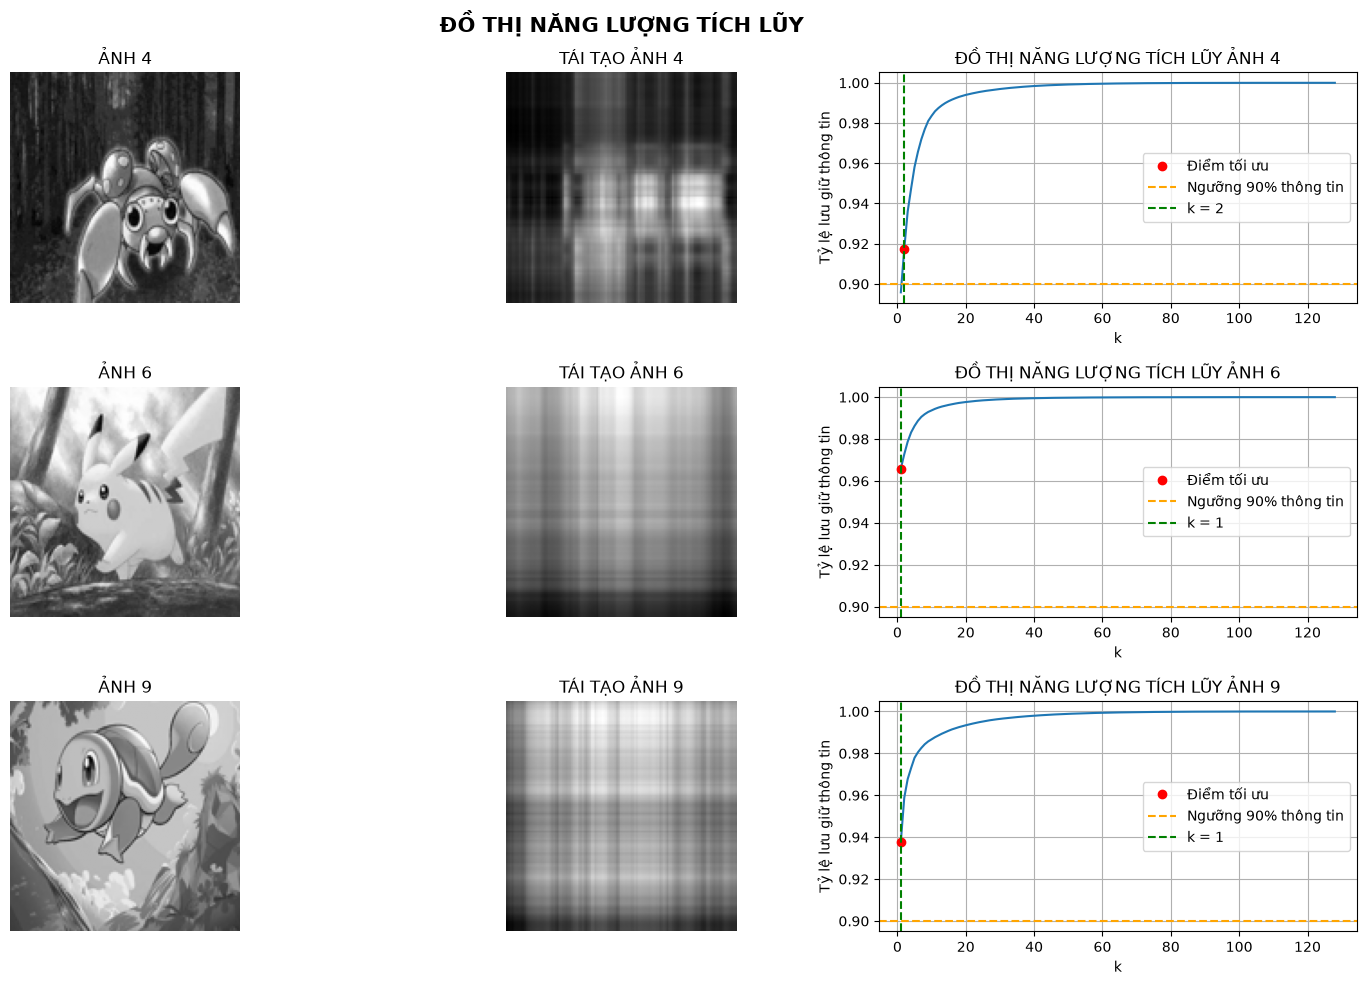

In [162]:
img_idx_test = [3, 5, 8]

fig, axs = plt.subplots(len(img_idx_test), 3, figsize=(len(img_idx_test)*5, 10))
fig.suptitle("ĐỒ THỊ NĂNG LƯỢNG TÍCH LŨY", fontsize=15, fontweight='bold')

for i in range(0, len(img_idx_test)):
    M = X[img_idx_test[i]].reshape(uniform_size)
    U, S, Vt = np.linalg.svd(M, full_matrices=False)

    energy_squared = S**2
    total_energy = sum(energy_squared)

    cumulative_energy = np.cumsum(energy_squared)/total_energy
    optimal_k = np.where(cumulative_energy >= 0.90)[0][0]+1

    axs[i][0].imshow(M, cmap='gray')
    axs[i][0].axis('off')
    axs[i][0].set_title(f"ẢNH {img_idx_test[i] + 1}")

    axs[i][1].imshow(reconstruct(optimal_k), cmap='gray')
    axs[i][1].axis('off')
    axs[i][1].set_title(f"TÁI TẠO ẢNH {img_idx_test[i] + 1}")

    axs[i][2].set_title(f"ĐỒ THỊ NĂNG LƯỢNG TÍCH LŨY ẢNH {img_idx_test[i] + 1}")
    axs[i][2].plot(range(1, len(cumulative_energy) + 1), cumulative_energy)
    axs[i][2].set_xlabel("k")
    axs[i][2].set_ylabel("Tỷ lệ lưu giữ thông tin")
    axs[i][2].grid(True)

    axs[i][2].plot(optimal_k, cumulative_energy[optimal_k - 1], 'ro', label="Điểm tối ưu")
    axs[i][2].axhline(y = 0.90, linestyle='--', color='orange', label="Ngưỡng 90% thông tin")
    axs[i][2].axvline(x = optimal_k, linestyle='--', color='green', label=f"k = {optimal_k}")

    axs[i][2].legend()


fig.tight_layout()
plt.show()

### **Đánh giá đồ thị năng lượng tích lũy:**
* Việc áp dụng các mức `k` nhỏ đã lưu trữ được hơn $90\%$ thông tin của bức ảnh nghe có vẻ tuyệt vời, tuy nhiên ảnh tái tạo cho thấy bản chất thông tin được lưu trữ chỉ là độ sáng tổng quát của bức ảnh và chưa làm rõ các chi tiết. 
* Do đó cần áp dụng các mức `k` cao hơn để lưu giữ các chi tiết quan trọng của bức ảnh.